<a href="https://colab.research.google.com/github/Madelavishnu/Pytorch/blob/main/Multiclass_classification_on_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
import torch
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

x_blob, y_blob = make_blobs(n_samples = 1000,
                            n_features = 2,
                            centers = 4,
                            cluster_std= 1.5,
                            random_state = 42)

x_blob = torch.from_numpy(x_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.long)

In [88]:
x_blob_train, x_blob_test, y_blob_train, y_blob_test = train_test_split(x_blob,y_blob, test_size = 0.2, random_state = 42)
x_blob.size(), x_blob_train.size()

(torch.Size([1000, 2]), torch.Size([800, 2]))

In [89]:
y_blob[:10]

tensor([3, 2, 2, 1, 1, 2, 1, 2, 2, 1])

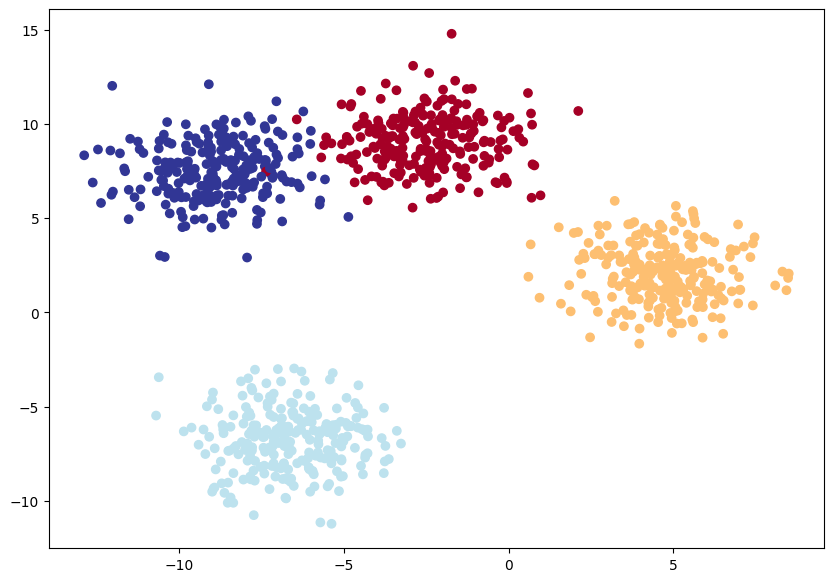

In [90]:
plt.figure(figsize=(10,7))

plt.scatter(x_blob[:,0],x_blob[:,1], c = y_blob, cmap = plt.cm.RdYlBu);

In [91]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [92]:
x_blob_train.shape,torch.unique(y_blob_train)   # x 2 input features  y has 4

(torch.Size([800, 2]), tensor([0, 1, 2, 3]))

In [93]:
y_blob_train[:10]

tensor([1, 0, 2, 2, 0, 0, 0, 1, 3, 0])

In [94]:
import torch.nn as nn

class BlobModel(nn.Module):
  def __init__(self,input_features,output_features,hidden_units):
    super().__init__()

    self.linear_layer = nn.Sequential(
        nn.Linear(in_features = input_features, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units, out_features = output_features)
    )

  def forward(self,x):
    return self.linear_layer(x)

model_0 = BlobModel(input_features = 2, output_features = 4, hidden_units = 8).to(device)

model_0


BlobModel(
  (linear_layer): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [95]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [96]:
x_blob_test.device   # we need to change this

device(type='cpu')

In [97]:
loss_fn  = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.01)

In [98]:
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(x_blob_test.to(device))

y_logits[:5]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834]], device='cuda:0')

In [99]:
y_pred_probs = torch.softmax(y_logits , dim = 1)

y_pred_probs[:5]


tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463]], device='cuda:0')

In [100]:
y_preds = torch.argmax(y_pred_probs, dim = 1)
y_preds

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1], device='cuda:0')

In [101]:
from sklearn.metrics import accuracy_score




In [102]:
y_blob_train.shape,y_logits.shape

(torch.Size([800]), torch.Size([200, 4]))

In [103]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs = 100

x_blob_train, y_blob_train = x_blob_train.to(device), y_blob_train.to(device)
x_blob_test, y_blob_test = x_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):

    model_0.train()

    # Forward pass
    y_logits = model_0(x_blob_train)


    loss = loss_fn(y_logits, y_blob_train)

    # Accuracy (argmax only for accuracy)
    y_pred = torch.argmax(y_logits, dim=1)
    acc = accuracy_score(
        y_true=y_blob_train.cpu(),
        y_pred=y_pred.cpu()
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Testing
    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(x_blob_test)
        test_loss = loss_fn(test_logits, y_blob_test)

        test_preds = torch.argmax(test_logits, dim=1)
        test_acc = accuracy_score(
            y_true=y_blob_test.cpu(),
            y_pred=test_preds.cpu()
        )

    if epoch % 10 == 0:
        print(
            f"epoch: {epoch} | "
            f"loss: {loss:.4f}, acc: {acc*100:.2f}% | "
            f"test_loss: {test_loss:.4f}, test_acc: {test_acc*100:.2f}%"
        )


epoch: 0 | loss: 1.1588, acc: 40.38% | test_loss: 1.1472, test_acc: 38.50%
epoch: 10 | loss: 1.0649, acc: 55.38% | test_loss: 1.0684, test_acc: 50.50%
epoch: 20 | loss: 0.9819, acc: 62.62% | test_loss: 0.9976, test_acc: 57.50%
epoch: 30 | loss: 0.9114, acc: 70.50% | test_loss: 0.9360, test_acc: 67.00%
epoch: 40 | loss: 0.8529, acc: 88.38% | test_loss: 0.8834, test_acc: 87.50%
epoch: 50 | loss: 0.8043, acc: 92.12% | test_loss: 0.8385, test_acc: 93.00%
epoch: 60 | loss: 0.7635, acc: 93.62% | test_loss: 0.7998, test_acc: 94.50%
epoch: 70 | loss: 0.7285, acc: 94.88% | test_loss: 0.7659, test_acc: 95.00%
epoch: 80 | loss: 0.6977, acc: 95.62% | test_loss: 0.7356, test_acc: 95.00%
epoch: 90 | loss: 0.6698, acc: 96.38% | test_loss: 0.7076, test_acc: 96.50%


In [104]:
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(x_blob_test)
  y_pred = torch.softmax(y_logits, dim = 1).argmax(dim = 1)

y_logits[:10],y_pred[:20]

(tensor([[-1.5520,  1.7702, -3.0464, -2.5323],
         [-0.1348, -2.3305, -2.3721,  0.0972],
         [ 0.1727, -0.2462,  0.3317, -0.0312],
         [-0.9623,  1.3257, -1.6128, -1.5732],
         [ 0.0045, -2.1045, -3.4698, -0.7000],
         [-0.2060, -2.6914, -2.7822,  0.1333],
         [ 0.0815, -0.3303,  0.2308, -0.0381],
         [ 0.0133, -2.3748, -2.8843, -0.2998],
         [ 0.1518, -0.3270,  0.2987, -0.0882],
         [ 0.0534, -2.3575, -2.9727, -0.3954]], device='cuda:0'),
 tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3],
        device='cuda:0'))

In [105]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


Text(0.5, 1.0, 'Test')

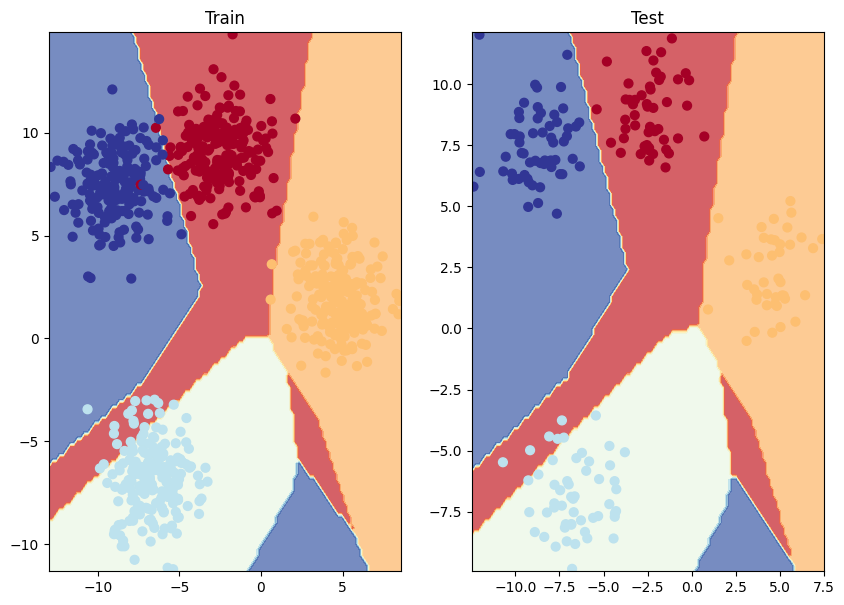

In [106]:
plt.figure(figsize=(10,7))

plt.subplot(1,2,1)
plot_decision_boundary(model_0, x_blob_train, y_blob_train)
plt.title("Train")

plt.subplot(1,2,2)
plot_decision_boundary(model_0, x_blob_test, y_blob_test)
plt.title("Test")
